#### [260706]_MNIST <hr>
- train.csv 6만개 -> 2만개
- test.csv  1만개 -> 3천개
- 다중분류 10개 
- 모델 클래스, 데이터셋 클래스
- 학습, 검증  사용자정의 함수
- 학습 후 시각화 
- ----------------------------------------

In [10]:
import pandas as pd, numpy as np, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib
sys.path.append('./custom_dataset.py')
from custom_dataset import *
from torch.utils.data import Dataset, TensorDataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [11]:
# 데이터 준비 및 확인
train_df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/mnist_train.csv', header=None)
test_df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/mnist_test.csv', header=None)

# 학습/테스트 데이터 개수 제한 : 6만개 -> 2만개, 1만개 -> 3천개
train_df = train_df[:20000]
test_df = test_df[:3000]

display(train_df.head(2))
display(test_df.head(2))

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**[1]학습준비**
- 클래스 준비 : 모델, 데이터셋
- 학습 설정 : 학습 횟수, 배치 크기, 러닝 레이트, 이터레이션 개수
- 데이터셋 준비 : 학습용, 테스트용, 검증용

In [12]:
## 학습용/테스트용 데이터 파일 분리 =>완료
## 피쳐와 타겟 분리
x_train = train_df[ train_df.columns[1:] ]
y_train = train_df[ train_df.columns[0] ]

x_test = test_df[ test_df.columns[1:] ]
y_test = test_df[ test_df.columns[0] ]

print(f'[Train] {x_train.shape}, {y_train.shape}')
print(f'[TEST]  {y_test.shape}, {y_test.shape}')

[Train] (20000, 784), (20000,)
[TEST]  (3000,), (3000,)


In [13]:
# 학습용 : 검증용 = 80 :20
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print(f'{x_train.shape}, {y_train.shape}, {y_train.value_counts().to_list()}')
print(f'{x_valid.shape}, {y_valid.shape}, {y_test.value_counts().to_list()}')

(16000, 784), (16000,), [1825, 1674, 1661, 1611, 1595, 1577, 1556, 1543, 1538, 1420]
(4000, 784), (4000,), [340, 318, 316, 313, 306, 295, 286, 283, 272, 271]


In [ ]:
# 학습 관련 설정
# => 학습 횟수 : epoch
epochs = 50

# => 학습량 : 1번 학습 후 W,B 업데이트
bs = 1000

# => 반복횟수 : W,B 업데이트 횟수 -> 학습중 즉, 학습용 데이터 셋
iters = x_train.shape[0]//bs

# => W,B 값 보정 정도 : 러닝레잍,. 스텝사이즈. 0.1 ~ 0.001
LR = 0.001

In [ ]:
# 학습 관련 인스턴스들 : 모델, 데이터셋, 손실함수, 최적화
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

# 모델 인스턴스 생성
model = MnistClassifier()

# => 모델 최적화 인스턴스 생성
adam = Adam(model.parameters(), lr=LR)

# 손실함수 인스턴스 생성
criterion = nn.CrossEntropyLoss()

# 학습용|검증용|테스트용 데이터셋 인스턴스 생성
trainDS = IrisDataset(x_train, y_train.to_frame())
testDS  = IrisDataset(x_test, y_test.to_frame())
validDS = IrisDataset(x_valid, y_valid.to_frame())

trainDL = DataLoader(trainDS, batch_size=bs, shuffle=True, drop_last=True)
testDL = DataLoader(testDS, batch_size=bs, shuffle=True, drop_last=True)
validDL = DataLoader(validDS, batch_size=bs, shuffle=True, drop_last=True)

**[2] 학습 진행**
- epoch 단위 loss 저장 : 배치단위 loss 모두 저장 후 평균계산
- epoch 증가 될수록 loss 감소되어야 함 
- 학습용과 검증용 비교 진행 => 과대적합 체크 및 학습 중단 고려

In [23]:
## 성능지표
from sklearn.metrics import f1_score

## 에포크 단위 loss 저장용 변수 
lossEpoch, scoreEpoch = {'Train':[], 'Valid':[]},   {'Train':[], 'Valid':[]}

for epo in range(epochs+1):
    ## loss, score 저장 변수
    lossDict  = {'Train':[], 'Valid':[]}
    scoreDict = {'Train':[], 'Valid':[]}

    ## -------------------------------
    ## 모델 학습 모드 설정
    ## -------------------------------
    model.train()

    ## 배치 단위 학습 진행
    for data, target in trainDL:

        ## 순전파 진행 => 가중치 합계
        pre_target = model(data)

        ## 역전파 업데이트 위한 grad 초기화 
        ## => 모델의 모든 층의 W,b에 업데이트할 값 저장 속성 grad
        ## => 초기화 하지 않으면 누적 
        adam.zero_grad()

        ## 손실 계산 -> 주의: 손실함수마다 원하는 자료형, 형태가 다름!
        ## -> CrossEntropyLoss : 정답 타겟 - 1D, Long
        loss = criterion(pre_target, target.reshape(-1).long())

        ## 역전파 진행=> 새로운 W,b 값 계산 후 grad에 저장 
        loss.backward() 

        ## W,b 업데이트 
        adam.step()
    
        ## F1 점수계산 
        preNP   = pre_target.argmax(dim=1).detach().squeeze().numpy()
        labelNP = target.detach().squeeze().numpy()
        score   = f1_score(labelNP, preNP, average='macro')

        ## 배치단위 손실 저장
        lossDict['Train'].append(loss.item())
        scoreDict['Train'].append(score)

    # -------------------------------
    # 모델 검증 모드 설정
    # -------------------------------
    ## 역전파, 기울기계산 등 비활성화
    model.eval()

    ## W,b 텐서의 requires_grad=False
    with torch.no_grad():
        for data, target in validDL:
            # 예측
            pre_target = model(data)

            # 손실
            loss = criterion(pre_target, target.reshape(-1).long())

            # F1 점수
            preNP   = pre_target.argmax(dim=1).detach().squeeze().numpy()
            labelNP = target.detach().squeeze().numpy()
            score   = f1_score(labelNP, preNP, average='macro')

            # 손실 및 F1점수 저장 
            lossDict['Valid'].append(loss.item())
            scoreDict['Valid'].append(score)

    ## 에포크 단위 손실 평균값 저장 및 출력
    if not epo%1:
        for key_name in ['Train', 'Valid']:
            loss  = sum(lossDict[key_name])/len(lossDict[key_name])
            score = sum(scoreDict[key_name])/len(scoreDict[key_name])
            lossEpoch[key_name].append(loss)
            scoreEpoch[key_name].append(score)

        print(f"[EPOCH-{epo:04}] TRAIN LOSS :{lossEpoch['Train'][-1]:.7f}  SCORE :{scoreEpoch['Train'][-1]:.7f}", end=' ')
        print(f"   VALID LOSS :{lossEpoch['Valid'][-1]:.7f}  SCORE :{scoreEpoch['Valid'][-1]:.7f}")
        

[EPOCH-0000] TRAIN LOSS :0.0014342  SCORE :1.0000000    VALID LOSS :0.2601640  SCORE :0.9500561
[EPOCH-0001] TRAIN LOSS :0.0013524  SCORE :1.0000000    VALID LOSS :0.2619510  SCORE :0.9505606
[EPOCH-0002] TRAIN LOSS :0.0013015  SCORE :1.0000000    VALID LOSS :0.2632537  SCORE :0.9505147
[EPOCH-0003] TRAIN LOSS :0.0012492  SCORE :1.0000000    VALID LOSS :0.2636109  SCORE :0.9501168
[EPOCH-0004] TRAIN LOSS :0.0011872  SCORE :1.0000000    VALID LOSS :0.2648516  SCORE :0.9505515
[EPOCH-0005] TRAIN LOSS :0.0011364  SCORE :1.0000000    VALID LOSS :0.2665824  SCORE :0.9505553
[EPOCH-0006] TRAIN LOSS :0.0010822  SCORE :1.0000000    VALID LOSS :0.2667936  SCORE :0.9511667
[EPOCH-0007] TRAIN LOSS :0.0010417  SCORE :1.0000000    VALID LOSS :0.2666865  SCORE :0.9515495
[EPOCH-0008] TRAIN LOSS :0.0010024  SCORE :1.0000000    VALID LOSS :0.2679520  SCORE :0.9504151
[EPOCH-0009] TRAIN LOSS :0.0009617  SCORE :1.0000000    VALID LOSS :0.2699584  SCORE :0.9500023
[EPOCH-0010] TRAIN LOSS :0.0009321  SCOR

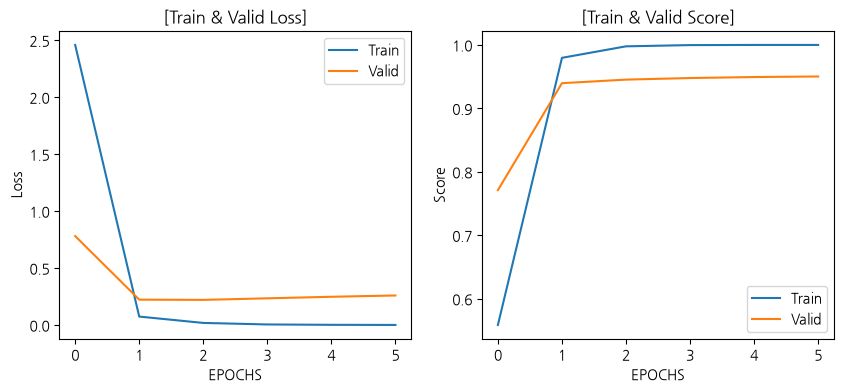

In [ ]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, title, epochList in zip(axes, ['Loss', 'Score'], [lossEpoch, scoreEpoch]):

    ax.plot(epochList['Train'], label = 'Train')
    ax.plot(epochList['Valid'], label = 'Valid')

    ax.set_title(f"[Train & Valid {title}]")
    ax.set_xlabel("EPOCHS")
    ax.set_ylabel(f"{title}")
    ax.legend()
plt.show()